# GAM vs. GLM: When to Use Each

## Overview

GAMs and GLMs address the same fundamental modeling problem but make different assumptions about the shape of predictor–response relationships. Choosing between them involves weighing flexibility against parsimony, interpretability, and the strength of your prior knowledge about the relationship.

| Criterion | GLM | GAM |
|---|---|---|
| Relationship shape | Assumed linear (on link scale) | Estimated from data — can be any shape |
| Parameters | Few, interpretable coefficients | Smooth functions — harder to summarize in a single number |
| Prediction | Extrapolates linearly beyond data | Extrapolation is unreliable — smooths can behave erratically outside data range |
| Overfitting risk | Lower (fewer parameters) | Higher — controlled by smoothing penalty and REML |
| Prior knowledge | Useful — can encode linear assumption | Less prior knowledge needed |
| Hypothesis testing | Standard likelihood-based tests | EDF-based tests; smooth significance |
| Sample size requirement | Smaller samples adequate | Smooths require sufficient data density along predictor range |

> **Rule of thumb:**  
> Start with a GLM. If residuals show non-linear patterns, or if you have strong biological/theoretical reason to expect non-linearity, fit a GAM. If the GAM's smooth EDFs are all approximately 1, the GLM was sufficient.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(mgcv)
library(gratia)
library(broom)
library(patchwork)

set.seed(42)
n <- 250

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'mgcv' was built under R version 4.4.3"
Loading required package: nlme


Attaching package: 'nlme'


The fo

---

## Scenario 1: GLM Is Sufficient

When the true relationship is genuinely linear on the link scale, the GLM and GAM should give equivalent results. The GAM's smooth EDF will be approximately 1.

GLM:
# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    1.34     0.0939      14.3 3.98e-34
2 x              0.323    0.0152      21.3 7.64e-58

GAM summary:
          edf   Ref.df  Chi.sq p-value
s(x) 1.007493 1.014945 508.685       0

GAM smooth EDF: 1.01 (close to 1 = effectively linear)


,df,AIC
,<dbl>,<dbl>
glm_lin,2.000000,1918.292
gam_lin,3.014945,1920.298


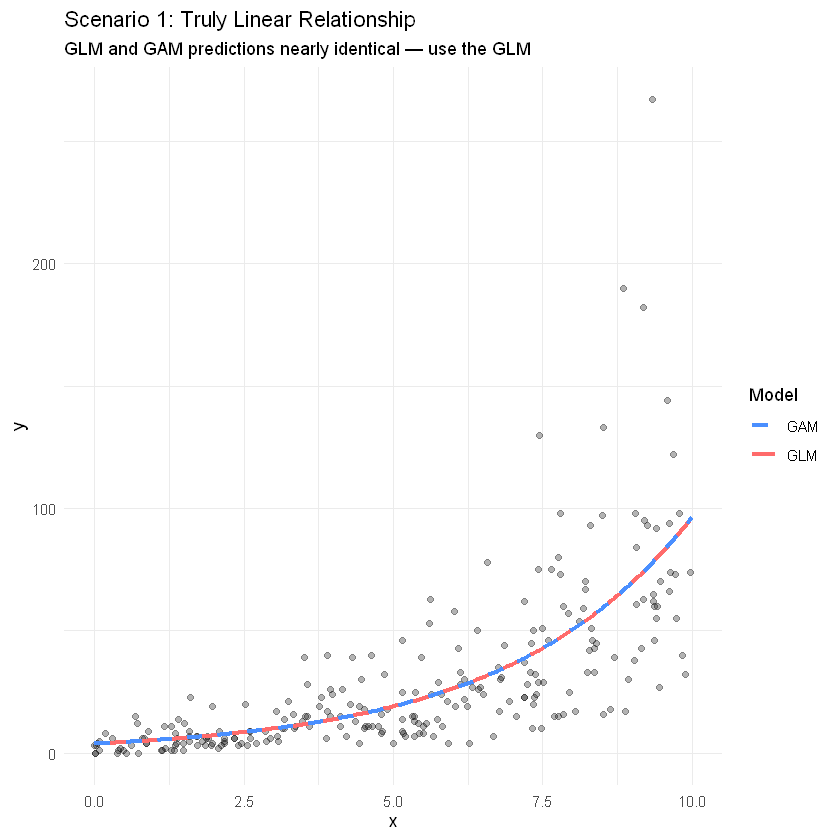

In [2]:
# ── Simulate truly linear relationship ───────────────────────────────────────
linear_data <- tibble(
  x  = runif(n, 0, 10),
  mu = exp(1.5 + 0.3 * x),
  y  = MASS::rnegbin(n, mu = mu, theta = 3)
) %>% select(-mu)

# ── Fit GLM and GAM ───────────────────────────────────────────────────────────
glm_lin <- glm(y ~ x,    data = linear_data, family = MASS::negative.binomial(theta = 3))
gam_lin <- mgcv::gam(y ~ s(x), data = linear_data, family = mgcv::nb(), method = "REML")

# ── Compare ───────────────────────────────────────────────────────────────────
cat("GLM:\n"); print(broom::tidy(glm_lin))
cat("\nGAM summary:\n"); print(summary(gam_lin)$s.table)
cat(sprintf("\nGAM smooth EDF: %.2f (close to 1 = effectively linear)\n",
            summary(gam_lin)$edf))

AIC(glm_lin, gam_lin)
# Similar AIC: GAM offers no advantage — use the simpler GLM

# ── Visual comparison ─────────────────────────────────────────────────────────
pred_grid <- data.frame(x = seq(0, 10, length.out = 200))
pred_grid$glm_pred <- predict(glm_lin, newdata = pred_grid, type = "response")
pred_grid$gam_pred <- predict(gam_lin, newdata = pred_grid, type = "response")

ggplot(linear_data, aes(x = x, y = y)) +
  geom_point(alpha = 0.3) +
  geom_line(data = pred_grid, aes(y = glm_pred, color = "GLM"), linewidth = 1.2) +
  geom_line(data = pred_grid, aes(y = gam_pred, color = "GAM"), linewidth = 1.2,
            linetype = "dashed") +
  scale_color_manual(values = c("#4a8fff", "#ff6b6b")) +
  labs(title = "Scenario 1: Truly Linear Relationship",
       subtitle = "GLM and GAM predictions nearly identical — use the GLM",
       color = "Model") +
  theme_minimal()

---

## Scenario 2: GAM Is Needed

When the true relationship is non-linear, a GLM will underfit, producing systematic residual patterns. The GAM captures the true shape.

GAM smooth EDF: 5.87 (well above 1 = non-linear)


,df,AIC
,<dbl>,<dbl>
glm_nonlin,2.000000,1883.259
gam_nonlin,8.056855,1217.241


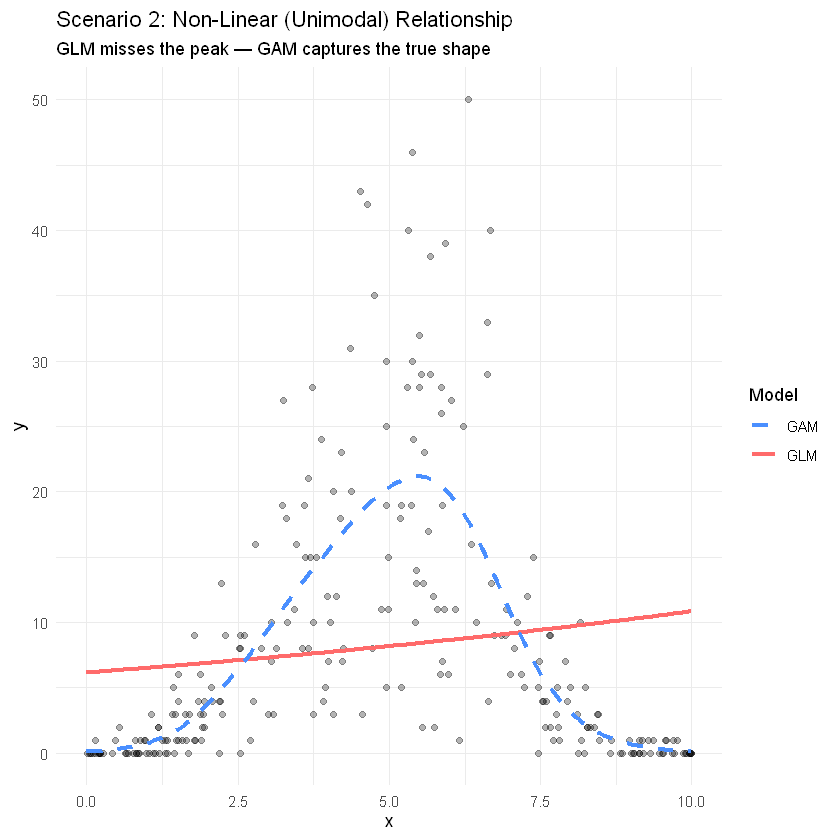

In [3]:
# ── Simulate non-linear (unimodal) relationship ───────────────────────────────
nonlin_data <- tibble(
  x  = runif(n, 0, 10),
  mu = exp(3 - 0.2 * (x - 5)^2),   # peaks at x = 5
  y  = MASS::rnegbin(n, mu = mu, theta = 3)
) %>% select(-mu)

# ── Fit GLM and GAM ───────────────────────────────────────────────────────────
glm_nonlin <- glm(y ~ x, data = nonlin_data, family = MASS::negative.binomial(theta = 3))
gam_nonlin <- mgcv::gam(y ~ s(x), data = nonlin_data, family = mgcv::nb(), method = "REML")

cat(sprintf("GAM smooth EDF: %.2f (well above 1 = non-linear)\n",
            summary(gam_nonlin)$edf))
AIC(glm_nonlin, gam_nonlin)
# Lower AIC for GAM: non-linearity is real and worth modeling

# ── Visual comparison ─────────────────────────────────────────────────────────
pred2 <- data.frame(x = seq(0, 10, length.out = 200)) %>%
  mutate(
    glm_pred = predict(glm_nonlin, newdata = ., type = "response"),
    gam_pred = predict(gam_nonlin, newdata = ., type = "response")
  )

ggplot(nonlin_data, aes(x = x, y = y)) +
  geom_point(alpha = 0.3) +
  geom_line(data = pred2, aes(y = glm_pred, color = "GLM"), linewidth = 1.2) +
  geom_line(data = pred2, aes(y = gam_pred, color = "GAM"), linewidth = 1.2,
            linetype = "dashed") +
  scale_color_manual(values = c("#4a8fff", "#ff6b6b")) +
  labs(title = "Scenario 2: Non-Linear (Unimodal) Relationship",
       subtitle = "GLM misses the peak — GAM captures the true shape",
       color = "Model") +
  theme_minimal()

---

## Formal Comparison: AIC and Likelihood Ratio Test

In [4]:
# ── AIC comparison workflow ───────────────────────────────────────────────────
# Fit both models using the same family
glm_model <- mgcv::gam(y ~ x,     data = nonlin_data,
                        family = mgcv::nb(), method = "ML")  # ML for AIC comparison
gam_model <- mgcv::gam(y ~ s(x),  data = nonlin_data,
                        family = mgcv::nb(), method = "ML")

# Note: fitting GLM via mgcv::gam() with a linear term ensures same family/estimator
# This avoids comparing AIC from different fitting engines

aic_table <- AIC(glm_model, gam_model) %>%
  mutate(delta_AIC = AIC - min(AIC))
print(aic_table)
# ΔAIC > 2: meaningful preference for lower-AIC model
# ΔAIC > 10: strong preference

# ── Likelihood ratio test: GLM nested within GAM ─────────────────────────────
anova(glm_model, gam_model, test = "Chisq")
# Significant: GAM provides significantly better fit than the linear version
# p > 0.05 + low ΔAIC: linear model is adequate

                df      AIC delta_AIC
glm_model 3.000000 1535.965  318.9068
gam_model 7.906175 1217.058    0.0000


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,248.0000,1529.965,NA,NA,NA
2,241.9612,1201.246,6.03882,328.7191,6.175136e-68


---

## Decision Guide

In [5]:
# ── Step-by-step decision workflow ───────────────────────────────────────────

# STEP 1: Examine scatterplots + loess curves
#   Approximately linear → fit GLM first
#   Clearly curved / unimodal / irregular → fit GAM

# STEP 2: Fit GLM, check residuals
#   Random residuals → GLM is adequate
#   Systematic curve in residuals → non-linearity present → fit GAM

# STEP 3: Fit GAM, check smooth EDFs
#   All EDFs ≈ 1 → linear model was sufficient, return to GLM
#   EDFs > 1 and significant → non-linearity is real, keep GAM

# STEP 4: Compare AIC (using ML estimation for both)
#   ΔAIC < 2: no meaningful advantage for GAM → prefer GLM (parsimony)
#   ΔAIC 2-10: moderate evidence for GAM
#   ΔAIC > 10: strong evidence for GAM

# STEP 5: Consider interpretability and the purpose of the model
#   Inference / explanation → GAM smooth plots communicate the relationship clearly
#   Prediction + extrapolation → GLM is safer beyond observed data range
#   Regulatory / operational use → GLM coefficients are more auditable

# ── Summary function ──────────────────────────────────────────────────────────
compare_glm_gam <- function(formula_lin, formula_gam, data, family) {
  m_glm <- mgcv::gam(formula_lin, data = data, family = family, method = "ML")
  m_gam <- mgcv::gam(formula_gam, data = data, family = family, method = "ML")

  aic_tab <- AIC(m_glm, m_gam) %>%
    mutate(model = c("GLM", "GAM"),
           delta_AIC = AIC - min(AIC)) %>%
    select(model, df, AIC, delta_AIC)

  edf_vals <- summary(m_gam)$edf

  cat("AIC Comparison:\n"); print(aic_tab)
  cat(sprintf("\nGAM smooth EDFs: %s\n",
              paste(round(edf_vals, 2), collapse = ", ")))
  cat(sprintf("Verdict: %s\n",
              ifelse(min(aic_tab$delta_AIC[aic_tab$model == "GAM"]) < 2 ||
                     all(edf_vals < 1.5),
                     "Linear GLM is adequate",
                     "GAM preferred — meaningful non-linearity detected")))
}

# Run on both scenarios
cat("=== Scenario 1 (linear) ===\n")
compare_glm_gam(y ~ x, y ~ s(x), linear_data, mgcv::nb())

cat("\n=== Scenario 2 (non-linear) ===\n")
compare_glm_gam(y ~ x, y ~ s(x), nonlin_data, mgcv::nb())

=== Scenario 1 (linear) ===
AIC Comparison:
      model       df      AIC    delta_AIC
m_glm   GLM 3.000000 1920.273 0.0000000000
m_gam   GAM 3.000386 1920.274 0.0004316956

GAM smooth EDFs: 1
Verdict: Linear GLM is adequate

=== Scenario 2 (non-linear) ===
AIC Comparison:
      model       df      AIC delta_AIC
m_glm   GLM 3.000000 1535.965  318.9067
m_gam   GAM 7.906239 1217.058    0.0000

GAM smooth EDFs: 5.71
Verdict: Linear GLM is adequate


---

## Common Pitfalls

**1. Defaulting to GAMs without checking whether the relationship is linear**  
GAMs are more complex and harder to communicate than GLMs. Always start simple — fit the GLM, check residuals, and only upgrade to a GAM if there is evidence of non-linearity.

**2. Comparing AIC from mgcv::gam() and stats::glm() directly**  
These are fit by different algorithms and their AIC values are not directly comparable. Use `mgcv::gam()` for both, with the linear term specified as a parametric term, to ensure a fair comparison.

**3. Using a GAM for extrapolation**  
GAM smooths are data-driven and can behave erratically outside the observed predictor range. For extrapolation, the linear GLM's assumption is usually safer (though still an assumption).

**4. Reporting GAM results only as EDF and p-values**  
Unlike GLMs, GAM coefficient tables don't tell the whole story. Always include smooth plots in presentations and publications — the shape of the effect is the main result.

**5. Treating a non-significant GAM smooth as evidence of no effect**  
A non-significant smooth (`p > 0.05`) could reflect genuine absence of an effect, insufficient power, or a smooth that needs a larger k. Check all three before concluding no effect exists.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*